## Tests preprocessing row-data csv to metrics.csv and fix.csv

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import random

Input :

In [2]:
path_row = '../data/1erDataset/data/Subject_1003_T1_Syllables_raw.csv'

In [3]:
df_row = pd.read_csv(path_row)
df_row = df_row[["time", "gaze_x_left", "gaze_y_left", "gaze_x_right", "gaze_y_right"]]
df_row.head()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right
0,328491191,146.24,155.97,161.65,161.52
1,328495189,145.10,155.34,159.05,162.17
2,328499187,142.61,153.04,160.49,162.19
3,328503186,141.55,149.98,162.91,162.88
4,328507184,139.31,146.80,163.20,163.24


average of both eyes :

In [4]:
df_row['fix_x'] = (df_row['gaze_x_left'] + df_row['gaze_x_right']) / 2
df_row['fix_y'] = (df_row['gaze_y_left'] + df_row['gaze_y_right']) / 2

df_row.head()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,fix_x,fix_y
0,328491191,146.24,155.97,161.65,161.52,153.945,158.745
1,328495189,145.10,155.34,159.05,162.17,152.075,158.755
2,328499187,142.61,153.04,160.49,162.19,151.550,157.615
3,328503186,141.55,149.98,162.91,162.88,152.230,156.430
4,328507184,139.31,146.80,163.20,163.24,151.255,155.020


Timestamp conversion :

In [5]:
df_row['time_ms'] = (df_row['time'] - df_row['time'][0]) / 1000

df_row.head()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,fix_x,fix_y,time_ms
0,328491191,146.24,155.97,161.65,161.52,153.945,158.745,0.000
1,328495189,145.10,155.34,159.05,162.17,152.075,158.755,3.998
2,328499187,142.61,153.04,160.49,162.19,151.550,157.615,7.996
3,328503186,141.55,149.98,162.91,162.88,152.230,156.430,11.995
4,328507184,139.31,146.80,163.20,163.24,151.255,155.020,15.993


test script convert :

In [6]:
def detect_fixations(
    times:       np.ndarray,   # timestamps en ms (array 1D, relatifs)
    xs:          np.ndarray,   # coordonnées x cyclope (array 1D)
    ys:          np.ndarray,   # coordonnées y cyclope (array 1D)
    disp_thresh: float = 150,   # seuil de dispersion en pixels
    min_dur:     float = 50,   # durée minimale d'une fixation en ms
) -> pd.DataFrame:
    """
    Détecte les fixations par I-DT (Identification by Dispersion Threshold).
    Salvucci & Goldberg (2000).

    Paramètres
    ----------
    times       : timestamps en ms, triés, relatifs (commencent à 0)
    xs, ys      : coordonnées du regard cyclope (même longueur que times)
    disp_thresh : fenêtre considérée comme fixation si
                  (x_max - x_min) + (y_max - y_min) <= disp_thresh
    min_dur     : une fenêtre n'est validée comme fixation que si sa durée >= min_dur

    Retourne
    --------
    DataFrame avec colonnes : duration_ms, fix_x, fix_y
    """
    n = len(times)
    fixations = []
    i = 0

    while i < n:

        # — Étendre la fenêtre vers la droite tant que la dispersion est ok —
        j = i + 1
        while j < n:
            disp = (xs[i:j+1].max() - xs[i:j+1].min()) + \
                   (ys[i:j+1].max() - ys[i:j+1].min())
            if disp > disp_thresh:
                break
            j += 1

        duration = times[j - 1] - times[i]

        if duration >= min_dur:
            # ✅ Fixation validée → centroïde de la fenêtre
            fixations.append({
                "duration_ms": round(duration, 2),
                "fix_x":       round(xs[i:j].mean(), 2),
                "fix_y":       round(ys[i:j].mean(), 2),
            })
            i = j       # reprendre après la fixation

        else:
            i += 1      # point de saccade ou bruit → avancer d'un sample

    return pd.DataFrame(fixations, columns=["duration_ms", "fix_x", "fix_y"])

<Axes: >

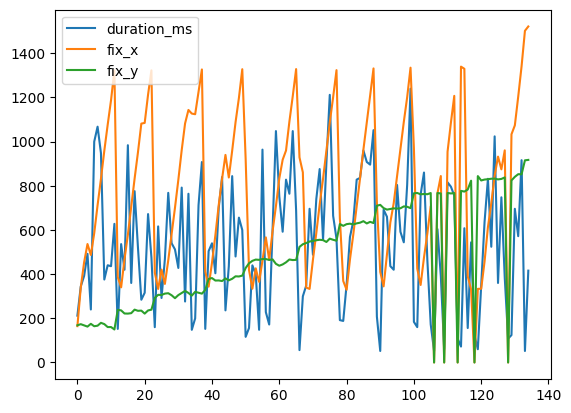

In [7]:
df_fix_create = detect_fixations(df_row['time_ms'], df_row['fix_x'], df_row['fix_y'])
df_fix_create.plot()

In [8]:
def compute_metrics(fixations: pd.DataFrame) -> pd.DataFrame:
    """
    Calcule les métriques globales d'un trial à partir des fixations détectées.

    Paramètres
    ----------
    fixations : DataFrame avec colonnes duration_ms, fix_x, fix_y
                (sortie de detect_fixations_idt)

    Retourne
    --------
    DataFrame 1 ligne avec :
      - mean_fix_dur_trial   : durée moyenne des fixations (ms)
      - n_fix_trial          : nombre de fixations
      - mean_sacc_ampl_trial : amplitude moyenne des saccades (pixels)
                               = distance euclidienne entre fixations consécutives
    """
    if fixations.empty:
        return pd.DataFrame([{
            "mean_fix_dur_trial":   None,
            "n_fix_trial":          0,
            "mean_sacc_ampl_trial": None,
        }])

    # ── Durée moyenne des fixations ──────────────────────────────────────
    mean_fix_dur = fixations["duration_ms"].mean()

    # ── Nombre de fixations ──────────────────────────────────────────────
    n_fix = len(fixations)

    # ── Amplitude moyenne des saccades ───────────────────────────────────
    # Une saccade = vecteur entre la fin d'une fixation et le début de la suivante
    # On approxime par la distance euclidienne entre centroïdes consécutifs
    if n_fix > 1:
        dx = fixations["fix_x"].diff().dropna()
        dy = fixations["fix_y"].diff().dropna()
        amplitudes = np.sqrt(dx**2 + dy**2)
        mean_sacc_ampl = amplitudes.mean()
    else:
        mean_sacc_ampl = None   # pas de saccade avec une seule fixation

    return pd.DataFrame([{
        "mean_fix_dur_trial":   round(mean_fix_dur,   6),
        "n_fix_trial":          n_fix,
        "mean_sacc_ampl_trial": round(mean_sacc_ampl, 6) if mean_sacc_ampl is not None else None,
    }])

In [9]:
df_fix_create

,duration_ms,fix_x,fix_y
0,211.97,164.56,168.29
1,344.03,338.99,173.44
2,391.87,453.71,168.05
3,492.04,536.40,162.45
4,239.93,486.92,175.02
...,...,...,...
130,695.95,1073.54,840.66
131,571.93,1203.42,852.54
132,916.04,1341.17,852.20
133,52.00,1501.85,915.38


In [10]:
df_metrics_create = compute_metrics(df_fix_create)
df_metrics_create

,mean_fix_dur_trial,n_fix_trial,mean_sacc_ampl_trial
0,531.420593,135,236.929789


outputs :

In [11]:
path_metrics = '../data/1erDataset/data/Subject_1003_T1_Syllables_metrics.csv'
path_fix = '../data/1erDataset/data/Subject_1003_T1_Syllables_fixations.csv'

In [12]:
df_metrics = pd.read_csv(path_metrics)
df_metrics = df_metrics[["mean_fix_dur_trial", "n_fix_trial", "mean_sacc_ampl_trial"]]
df_metrics.head(1)

,mean_fix_dur_trial,n_fix_trial,mean_sacc_ampl_trial
0,497.664478,136,139.050134


<Axes: >

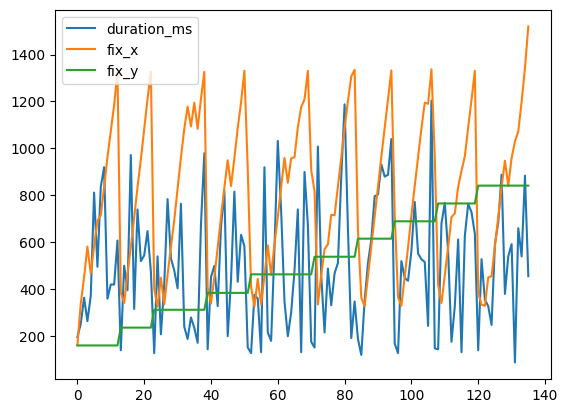

In [13]:
df_fix = pd.read_csv(path_fix)
df_fix = df_fix[["duration_ms", "fix_x", "fix_y"]]
df_fix.plot()

In [14]:
import I2MC

In [15]:
# ── I2MC / recording parameters ───────────────────────────────────────────────
FREQ_HZ      = 250
MIN_FIX_MS   = 40
SCREEN_X     = 1920
SCREEN_Y     = 1080
MISSING_VAL  = -32768
MAX_MERGE_DIST = 30
MAX_MERGE_DIST = 30

In [16]:
def run_i2mc(raw_df):
    gaze = pd.DataFrame({
        'time': raw_df['time'] / 1000.0,   # µs → ms
        'L_X' : raw_df['gaze_x_left'],
        'L_Y' : raw_df['gaze_y_left'],
        'R_X' : raw_df['gaze_x_right'],
        'R_Y' : raw_df['gaze_y_right'],
    })
    options = {
        'xres'        : SCREEN_X,
        'yres'        : SCREEN_Y,
        'freq'        : FREQ_HZ,
        'missingx'    : MISSING_VAL,
        'missingy'    : MISSING_VAL,
        'minFixDur'   : MIN_FIX_MS,
        'maxMergeDist': MAX_MERGE_DIST,
        'maxMergeTime': MAX_MERGE_DIST,
    }
    result = I2MC.I2MC(gaze, options, logging=False)

    fix, _, _ = result
    return fix

/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


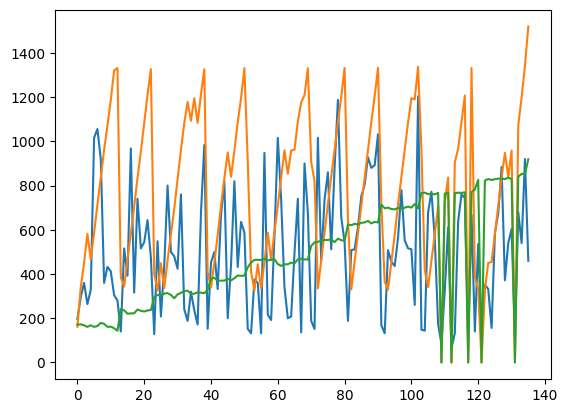

In [17]:
df_fix_create_i2mc = pd.DataFrame(run_i2mc(df_row))[['dur', 'xpos', 'ypos']]
df_fix_create_i2mc = df_fix_create_i2mc.rename(columns={"dur": "duration_ms", "xpos": "fix_x", "ypos": "fix_y"})
plt.plot(df_fix_create_i2mc)

## Compere results

Text(0.5, 1.0, 'Calculate 2 fix.csv')

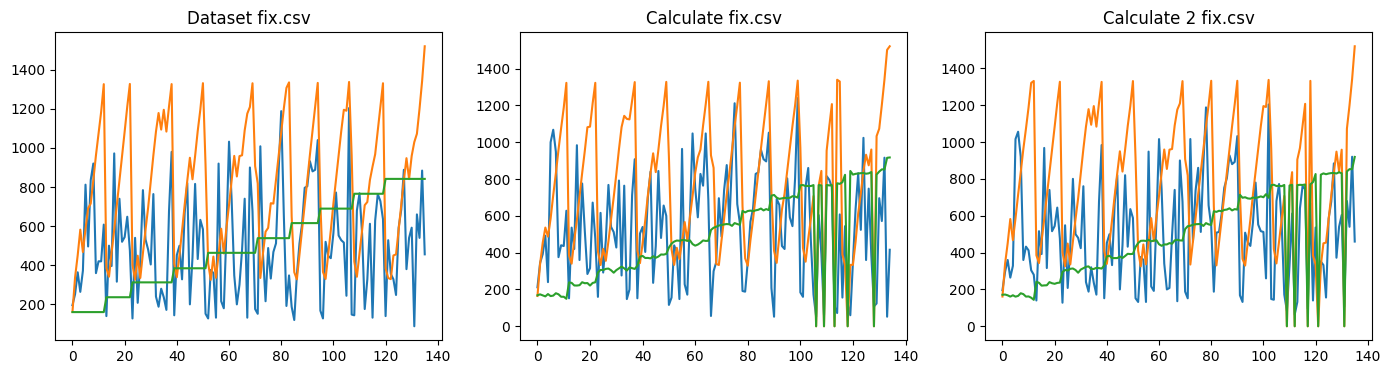

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(df_fix)
ax[0].set_title("Dataset fix.csv")

ax[1].plot(df_fix_create)
ax[1].set_title("Calculate fix.csv")

ax[2].plot(df_fix_create_i2mc)
ax[2].set_title("Calculate 2 fix.csv")

In [19]:
df_metrics.head(1)

,mean_fix_dur_trial,n_fix_trial,mean_sacc_ampl_trial
0,497.664478,136,139.050134


In [20]:
df_metrics_create

,mean_fix_dur_trial,n_fix_trial,mean_sacc_ampl_trial
0,531.420593,135,236.929789


In [21]:
df_metrics_create_2 = compute_metrics(df_fix_create_i2mc)
df_metrics_create_2

,mean_fix_dur_trial,n_fix_trial,mean_sacc_ampl_trial
0,501.016015,136,243.525536


The i2mc results seem more similar to our target output

## Optimizing parameters for I2MC

In [22]:
df_row.head()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,fix_x,fix_y,time_ms
0,328491191,146.24,155.97,161.65,161.52,153.945,158.745,0.000
1,328495189,145.10,155.34,159.05,162.17,152.075,158.755,3.998
2,328499187,142.61,153.04,160.49,162.19,151.550,157.615,7.996
3,328503186,141.55,149.98,162.91,162.88,152.230,156.430,11.995
4,328507184,139.31,146.80,163.20,163.24,151.255,155.020,15.993


In [23]:
def detect_fixations_i2mc(raw_df):

    freq = 1000 / raw_df["time_ms"].diff().median()
    print(f"FREQ : {freq:.1f} Hz")
    FREQ_HZ      = freq

    min_fix_ms = max(100, 2 * (1000 / FREQ_HZ))
    print(f"MIN_FIX_MS : {min_fix_ms}ms, during reading, fixations typically last 150–400ms")
    MIN_FIX_MS   = min_fix_ms

    SCREEN_X     = 1920
    SCREEN_Y     = 1080
    MISSING_VAL  = -32768

    # Merges two fixations separated by a micro-stutter if they are less than N pixels apart
    MAX_MERGE_DIST = 30
    MAX_MERGE_TIME = 30

    gaze = pd.DataFrame({
        'time': raw_df['time_ms'],
        'L_X' : raw_df['gaze_x_left'],
        'L_Y' : raw_df['gaze_y_left'],
        'R_X' : raw_df['gaze_x_right'],
        'R_Y' : raw_df['gaze_y_right'],
    })
    options = {
        'xres'        : SCREEN_X,
        'yres'        : SCREEN_Y,
        'freq'        : FREQ_HZ,
        'missingx'    : MISSING_VAL,
        'missingy'    : MISSING_VAL,
        'minFixDur'   : MIN_FIX_MS,
        'maxMergeDist': MAX_MERGE_DIST,
        'maxMergeTime': MAX_MERGE_TIME,
    }
    result = I2MC.I2MC(gaze, options, logging=False)
    fix, _, _ = result
    df_fix = pd.DataFrame(fix)
    df_fix = df_fix[['dur', 'xpos', 'ypos']]
    df_fix = df_fix.rename(columns={"dur": "duration_ms", "xpos": "fix_x", "ypos": "fix_y"})
    return df_fix

In [24]:
detect_fixations_i2mc(df_row).head()

FREQ : 250.0 Hz
MIN_FIX_MS : 100ms, during reading, fixations typically last 150–400ms


/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,duration_ms,fix_x,fix_y
0,195.970,161.4900,170.9400
1,296.022,339.2375,172.3700
2,359.875,450.5950,168.0200
3,264.002,582.0225,161.0100
4,328.014,467.2600,168.2525


In [35]:
from preprocessing_scripts.row_to_metrics import row_to_metrics

row_to_metrics(df_row)

/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/maelle/.pyenv/versions/3.10.6/envs/dyslexia/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,mean_fix_dur_trial,n_fix_trial,mean_sacc_ampl_trial
0,497.738358,137,241.90466


## Test with data from our app

In [26]:
path_our = '../eyes-tracking/exports/gaze_log (3).csv'

In [27]:
df_our_row = pd.read_csv(path_our)
df_our_row.head()

,time,fix_x,fix_y,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right
0,1.780490e+09,395,568,429,656,398,488
1,1.780490e+09,395,571,421,689,353,554
2,1.780490e+09,399,563,476,594,344,471
3,1.780490e+09,404,573,504,686,309,580
4,1.780490e+09,408,581,486,679,361,528


In [28]:
df_our_row['time_ms'] = (df_our_row['time'] - df_our_row['time'].iloc[0]) * 1000
df_our_row.head()

,time,fix_x,fix_y,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,time_ms
0,1.780490e+09,395,568,429,656,398,488,0.000000
1,1.780490e+09,395,571,421,689,353,554,36.246061
2,1.780490e+09,399,563,476,594,344,471,100.330114
3,1.780490e+09,404,573,504,686,309,580,136.554003
4,1.780490e+09,408,581,486,679,361,528,169.632196


In [29]:
df_our_row.dtypes

time            float64
fix_x             int64
fix_y             int64
gaze_x_left       int64
gaze_y_left       int64
gaze_x_right      int64
gaze_y_right      int64
time_ms         float64
dtype: object

In [30]:
df_our_fix_create = detect_fixations(df_our_row['time_ms'], df_our_row['fix_x'], df_our_row['fix_y'])
df_our_fix_create

,duration_ms,fix_x,fix_y
0,460.03,420.36,578.36
1,133.33,516.00,503.00
2,535.71,561.15,370.92
3,598.89,552.92,297.23
4,666.54,688.62,279.81
...,...,...,...
67,99.31,602.00,410.67
68,598.30,471.29,447.71
69,98.92,316.00,430.00
70,99.16,158.00,411.00


<Axes: >

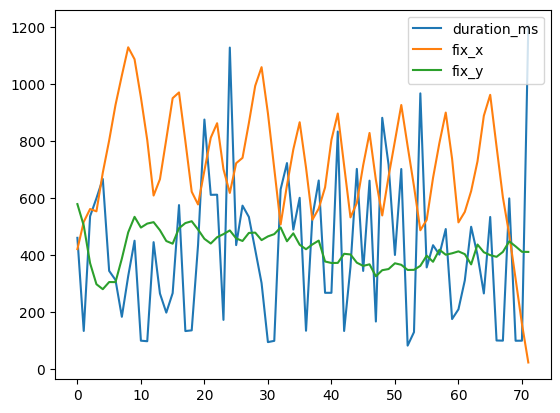

In [31]:
df_our_fix_create.plot()